In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism
from neuron import h
import plotly.graph_objects as go
import matplotlib.colors as mcolors
from neuron.units import ms, mV
import plotly.io as pio
from matplotlib import pyplot, cm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")

morphologyFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc"
biophysicalModelTemplateFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/PFCtemplate.hoc"

h.load_file(biophysicalModelTemplateFilename)



/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampain.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampa.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/cadynin.mod" "/home/wzl/L

--No graphics will be displayed.


1.0

In [11]:
run_dt=0.1
neuron = h.FScell(morphologyFilename)   
h.dt = run_dt
h.tstop = 200.
h.v_init = -65.
Vclamp_init = -50.
    
time = h.Vector().record(h._ref_t)
recv = h.Vector().record(neuron.soma[0](0.5)._ref_v)


# Initialize voltage clamp
vclamp = h.SEClamp(neuron.soma[0](0.5))
vclamp.amp1 = Vclamp_init
vclamp.dur1 = h.tstop
vclamp.dur2 = h.tstop
vclamp.amp2 = Vclamp_init - 20.



# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()
    
def verfication(GL, C, t, I):
    
    v = np.zeros(len(t))
    for i in range(len(t)-1):
        v[i+1] = v[i] + run_dt/C*(-GL*v[i]+I[i])
        
    return v
    


go()
recv0 = np.array(recv.to_python())



Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


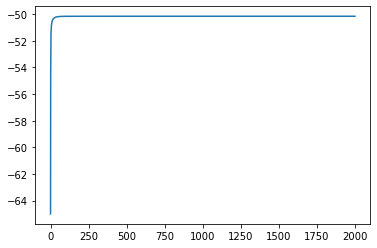

In [12]:
plt.plot(recv0)

In [13]:
v_vals = [seg.v for sec in h.allsec() for seg in sec]
print(np.min(v_vals), np.max(v_vals))

-70.947131709698 -50.15425324488091


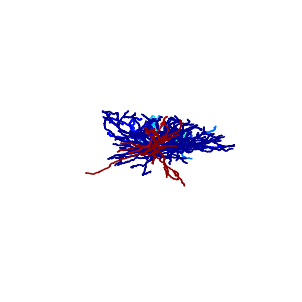

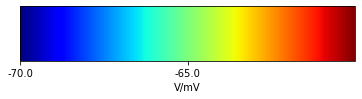

In [7]:
from neuron import h
from matplotlib import pyplot as plt

cmap=cm.jet
v_vals = [seg.v for sec in h.allsec() for seg in sec]
minv = -70.
maxv = -60.
colorbarlabel = 'V/mV'
ticklabels = True
tickmin = -70.
tickmax = -60.
dt = 5


# 绘图设置
ps = h.PlotShape(False)  # 创建PlotShape对象
ps.show(0)  # 不自动显示NEURON的窗口
ps.variable('v')
ps.scale(minv, maxv)

# 使用Matplotlib进行绘图
ax = ps.plot(pyplot, cmap=cmap)

# # # 设置坐标轴范围
# ax.set_xlim([-300, 300])  # 设置x轴范围
# ax.set_ylim([0, 1400])  # 设置y轴范围
# ax.set_zlim([-600, 0])  # 设置z轴范围

# ps.view(-400,0, 0, 300, 0, 300, 100, 500)
# ax.view_init(elev=280, azim=98)
ax.grid(False)
# 关闭坐标轴
ax.axis('off')
# plt.savefig("/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/L5PC_neuron/figure/space_clamp_error.eps", format='eps', dpi=300)
plt.show()

# 创建自定义的颜色映射
cmap = cmap
colormap = cm.ScalarMappable(cmap=cmap, 
        norm=mcolors.Normalize(vmin=minv, vmax=maxv))

# 创建一个新的图形和轴

fig, ax = plt.subplots(figsize=(6, 1))

# 绘制颜色条
cbar = plt.colorbar(colormap, cax=ax, orientation='horizontal')
cbar.set_label(colorbarlabel)
if ticklabels:
    cbar.set_ticks(np.arange(tickmin, tickmax, dt))
    cbar.set_ticklabels([f'{i}' for i in np.arange(tickmin, tickmax, dt)])

# # 设置图的边界
# plt.tight_layout()


# 显示图形（可选）
plt.show()

In [15]:
loc = np.arange(0,68,1)
dend_v= np.zeros(len(loc))
for i in range(len(loc)):
   dend_v[i] = neuron.dend[i].v
print(np.min(dend_v), np.max(dend_v))

-53.48784397651494 -50.161441045982066
